# GloVe -- Embedding Exploration

Loads the trained GloVe vectors from `models/` (the model recorded in `models/best.json` is the
primary one; the other tokenization is loaded alongside for comparison) and:

1. t-SNE projection of word embeddings to 2D, plotted.
2. Nearest-neighbor queries for a handful of Darija words.
3. Runs `Embeddings/intrinsic_eval/scripts/evaluate_embeddings.py`'s word-similarity and analogy
   evaluation against the model(s).
4. Unsupervised K-Means clustering of sentiment words (k=2).
5. Unsupervised K-Means clustering of entity-type words (k=4).
6. Words-vs-pieces comparison on those two clustering tasks.

The released vectors are `W + W~` (paper §4.2), `embeddings` in each `.npz`. Two GloVe variants exist
(both d=64, trained on the 10M longest comments of the big corpus, window 10 -- see `plan.md`):

- **words**: whole lowercased words, 20K vocabulary; a word outside the vocabulary has no vector (OOV).
- **pieces**: SentencePiece unigram-20K pieces; a word's vector is the mean of its pieces' vectors, so
  every word has a vector (same convention as the CBOW/skip-gram notebooks).

CPU is enough here (embedding lookups + sklearn). Unlike `word2vec_eval.ipynb`, this notebook needs no
corpus scan: the words model's vocabulary file is already frequency-ordered.

In [1]:
from __future__ import annotations

import json
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

import arabic_reshaper
import sentencepiece as spm

ALGO_DIR = Path.cwd().resolve()
if ALGO_DIR.name != "glove":
    ALGO_DIR = ALGO_DIR / "Embeddings" / "glove"
ROOT = ALGO_DIR.parents[1]  # glove -> Embeddings -> project root

sys.path.insert(0, str(ROOT / "Embeddings" / "intrinsic_eval" / "scripts"))

DATA_DIR = ALGO_DIR / "data"
MODELS_DIR = ALGO_DIR / "models"
SP_MODEL = ROOT / "Tokenization" / "models_bigcorpus" / "sentencepiece" / "unigram_20000.model"

# Arabic-safe label rendering. Tahoma/Arial must come before Segoe UI in the
# fallback list (Segoe UI doesn't render arabic_reshaper's presentation-form
# glyphs joined -- confirmed by a rendered comparison, see word2vec_attention's
# notebook history).
plt.rcParams["font.family"] = ["Tahoma", "Arial", "Segoe UI", "DejaVu Sans"]

ARABIC_RE = re.compile(r"[؀-ۿݐ-ݿࢠ-ࣿﭐ-﷿ﹰ-﻿]")
LATIN_RE = re.compile(r"[a-zA-ZÀ-ɏ]")


def render_label(text: str) -> str:
    """Reshape Arabic-script text into joined presentation-form glyphs for
    correct matplotlib display. Deliberately does NOT also apply
    bidi.get_display() -- this environment's matplotlib/font stack already
    lays reshaped RTL glyphs out correctly on its own (verified in
    word2vec_attention's notebook); get_display's extra reversal on top
    would produce a fully backwards word."""
    if ARABIC_RE.search(text):
        return arabic_reshaper.reshape(text)
    return text


def script_of(text: str) -> str:
    has_ar = bool(ARABIC_RE.search(text))
    has_lat = bool(LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"

In [2]:
best = json.loads((MODELS_DIR / "best.json").read_text(encoding="utf-8"))
print("best.json:", {k: best[k] for k in ("model_file", "mode", "dim", "batch_size")})

# The pieces counterpart trained with the same batch size as the chosen model.
words_file = best["model_file"] if best["mode"] == "words" else best["model_file"].replace("_pieces_", "_words_")
pieces_file = best["model_file"] if best["mode"] == "pieces" else best["model_file"].replace("_words_", "_pieces_")
E_words = np.load(MODELS_DIR / words_file)["embeddings"]      # (20000, 64)
E_pieces = np.load(MODELS_DIR / pieces_file)["embeddings"]    # (20000, 64)

vocab_words = json.loads((DATA_DIR / "vocab_words.json").read_text(encoding="utf-8"))  # frequency-ordered
word_id = {w: i for i, w in enumerate(vocab_words)}
sp = spm.SentencePieceProcessor(model_file=str(SP_MODEL))
PAD_ID = 0

print(f"words model:  {words_file}  {E_words.shape}   ({len(vocab_words):,}-word vocabulary)")
print(f"pieces model: {pieces_file}  {E_pieces.shape}")

best.json: {'model_file': 'glove_words_d64_b32k.npz', 'mode': 'words', 'dim': 64, 'batch_size': 32768}
words model:  glove_words_d64_b32k.npz  (20000, 64)   (20,000-word vocabulary)
pieces model: glove_pieces_d64_b32k.npz  (20000, 64)


In [3]:
def get_word_vector_words(word: str) -> np.ndarray | None:
    """Direct lookup of the lowercased word; None if it is outside the 20K vocabulary."""
    i = word_id.get(word.lower())
    return None if i is None else E_words[i]


def get_word_vector_pieces(word: str) -> np.ndarray | None:
    """SentencePiece-encode the word and mean-pool its pieces' vectors (single-piece word = direct
    lookup) -- same convention as word2vec_eval.ipynb's get_word_vector."""
    ids = [i for i in sp.encode(word) if i != PAD_ID and i < E_pieces.shape[0]]
    if not ids:
        return None
    return E_pieces[ids].mean(axis=0)


# The chosen model drives sections 1, 2, 4 and 5; sections 3 and 6 compare both.
get_word_vector = get_word_vector_words if best["mode"] == "words" else get_word_vector_pieces
MODEL_LABEL = f"GloVe {best['mode']} d={best['dim']}"

# Sanity check
v = get_word_vector("\u0628\u0632\u0627\u0641")  # bezzaf ("a lot")
print("vector shape:", None if v is None else v.shape)

vector shape: (64,)


## 1. t-SNE projection to 2D

Two groups, plotted together but colored separately:
- **frequent corpus words** -- sampled from the most frequent words in the model's vocabulary
  (`vocab_words.json` is already sorted by corpus frequency, so no corpus scan is needed).
  Placeholder tokens (`url`, `mention` -- from the `[URL]`/`[MENTION]` cleaning placeholders) are excluded.
- **curated Darija words** -- every word appearing in the intrinsic-eval word-similarity/analogy sets
  (those outside the words model's vocabulary are dropped, as they have no vector).

In [4]:
EVAL_DATA_DIR = ROOT / "Embeddings" / "intrinsic_eval" / "data"


def load_curated_words() -> list[str]:
    words: set[str] = set()
    with (EVAL_DATA_DIR / "word_similarity.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            words.add(row["word1"])
            words.add(row["word2"])
    with (EVAL_DATA_DIR / "analogy_pairs.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            cat = json.loads(line)
            for p in cat["pairs"]:
                words.add(p["word_a"])
                words.add(p["word_b"])
    return sorted(words)


curated_words = load_curated_words()
print(f"{len(curated_words)} unique curated words")

TOP_N_FREQUENT_WORDS = 300
FREQUENT_WORD_POOL_SIZE = 10000
PLACEHOLDER_WORDS = {"url", "mention"}  # lowercased [URL]/[MENTION] cleaning placeholders

# vocab_words is sorted by descending frequency; script_of() drops pure digit/punctuation "words".
frequent_word_pool = [
    w for w in vocab_words
    if script_of(w) in ("arabic", "latin", "mixed") and w not in PLACEHOLDER_WORDS
][:FREQUENT_WORD_POOL_SIZE]

# Randomly sampled (no fixed seed) -- a different subset each run, same convention as word2vec_eval.ipynb.
frequent_words = random.sample(frequent_word_pool, min(TOP_N_FREQUENT_WORDS, len(frequent_word_pool)))
print(f"{len(frequent_words)} frequent corpus words (randomly sampled from the top {len(frequent_word_pool)} by frequency)")

463 unique curated words
300 frequent corpus words (randomly sampled from the top 10000 by frequency)


In [5]:
frequent_words_set = set(frequent_words)
curated_words_deduped = [w for w in curated_words if w not in frequent_words_set]

plot_vectors = []
plot_labels = []
plot_groups = []  # "frequent" or "curated"

for w in frequent_words:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("frequent")

n_curated_oov = 0
for w in curated_words_deduped:
    v = get_word_vector(w)
    if v is not None:
        plot_vectors.append(v)
        plot_labels.append(w)
        plot_groups.append("curated")
    else:
        n_curated_oov += 1

X = np.stack(plot_vectors)
print(f"t-SNE input: {X.shape[0]} points, {X.shape[1]} dims ({n_curated_oov} curated words dropped as out-of-vocabulary)")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
coords = tsne.fit_transform(X)

t-SNE input: 631 points, 64 dims (123 curated words dropped as out-of-vocabulary)


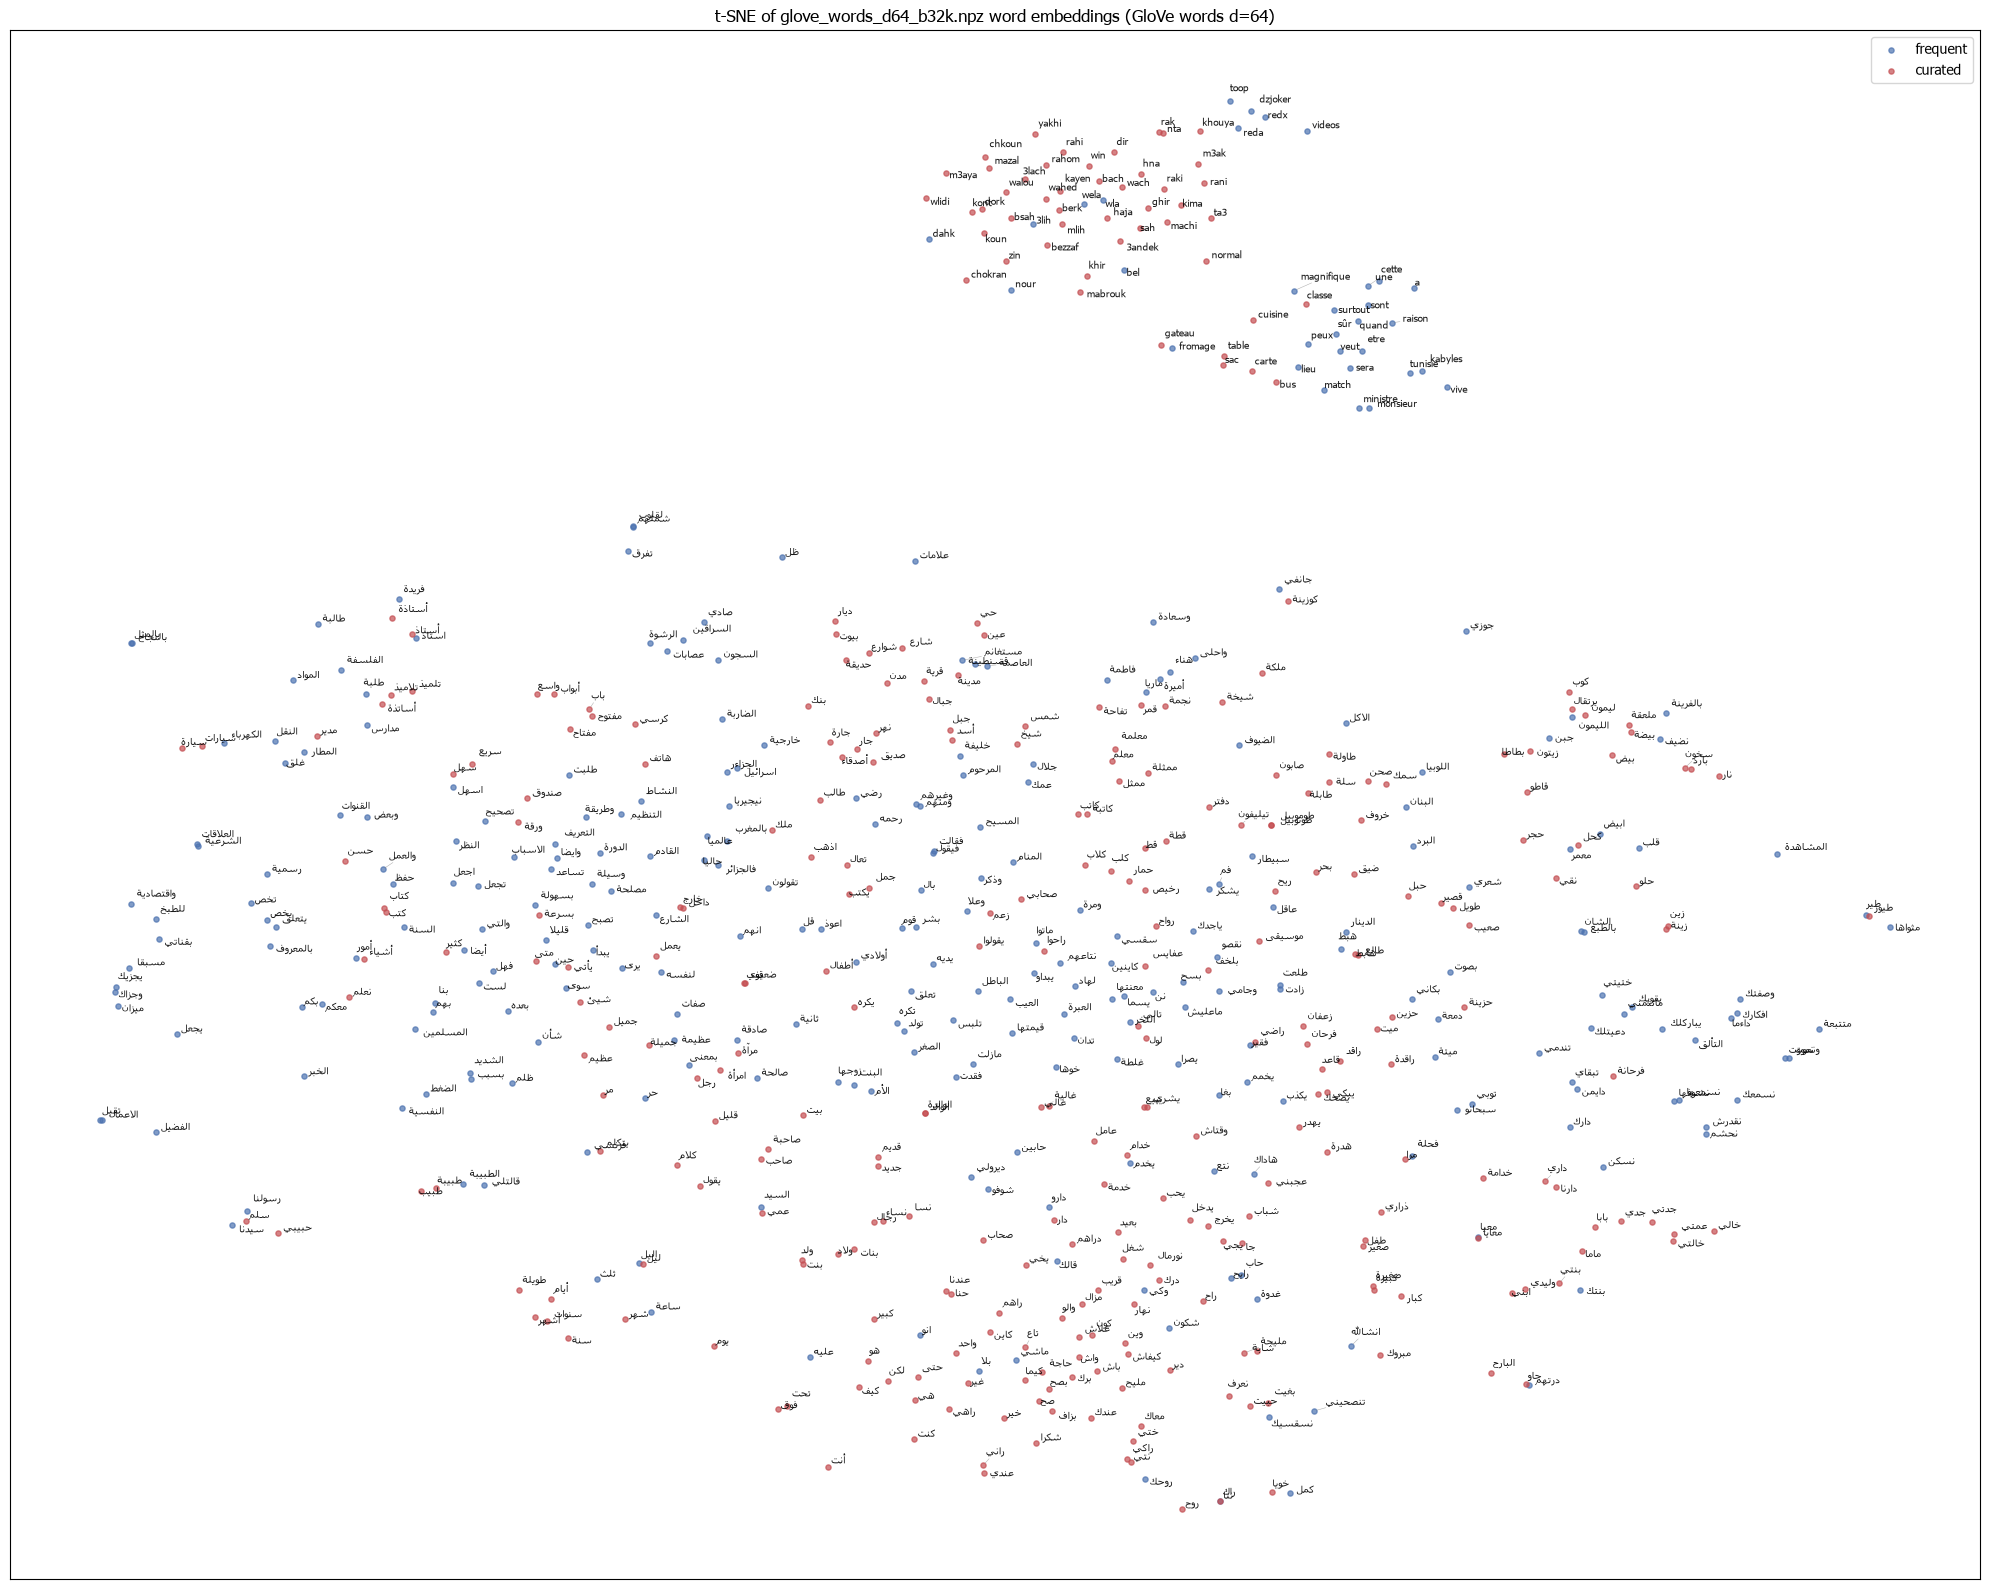

In [6]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(20, 16))

colors = {"frequent": "#4C72B0", "curated": "#C44E52"}
for group in ("frequent", "curated"):
    idx = [i for i, g in enumerate(plot_groups) if g == group]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=14, color=colors[group], alpha=0.7, label=group)

# adjustText repels overlapping labels apart and draws a thin line back to the true point (plain
# fixed-offset labels overlap into unreadable garbage at this point density).
texts = [
    ax.text(coords[i, 0], coords[i, 1], render_label(label), fontsize=7, alpha=0.9)
    for i, label in enumerate(plot_labels)
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.6))

ax.set_title(f"t-SNE of {best['model_file']} word embeddings ({MODEL_LABEL})")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Nearest neighbors

Unlike the skip-gram notebook (whose per-word vectors are mean-pooled pieces, so it can only rank a
small candidate pool), the words model has a real vector for every one of its 20,000 vocabulary
entries, so neighbors are ranked over the **whole vocabulary** by cosine similarity. When the chosen
model is the pieces variant, the pool falls back to the same points plotted above.

In [7]:
if best["mode"] == "words":
    pool_words, pool_matrix = vocab_words, E_words
else:
    pool_words, pool_matrix = plot_labels, X
pool_normed = pool_matrix / np.clip(np.linalg.norm(pool_matrix, axis=1, keepdims=True), 1e-9, None)


def nearest_neighbors(word: str, k: int = 10) -> list[tuple[str, float]]:
    qv = get_word_vector(word)
    if qv is None:
        return []
    qv = qv / max(np.linalg.norm(qv), 1e-9)
    sims = pool_normed @ qv
    results: list[tuple[str, float]] = []
    for i in np.argsort(-sims):
        w = pool_words[i]
        if w == word.lower():
            continue
        results.append((w, float(sims[i])))
        if len(results) >= k:
            break
    return results


demo_words = ["\u0628\u0632\u0627\u0641", "\u062e\u062f\u0645\u0629", "\u0648\u0627\u0634", "\u062d\u0628\u064a\u0628\u064a", "\u0645\u0644\u064a\u062d", "\u0648\u0644\u062f", "\u0628\u0646\u062a", "\u0632\u064a\u0646"]
# bezzaf, khedma, wach, hbibi, mlih, wled, bnt, zin

arabizi_demo_words = ["bezzaf", "wallah", "khoya", "hbibi", "zwin", "chkoun", "barca", "algerie"]

for w in demo_words + arabizi_demo_words:
    neighbors = nearest_neighbors(w, k=10)
    print(f"\n{w}:" + ("" if neighbors else "  (out of vocabulary)"))
    for nw, score in neighbors:
        print(f"  {score:.3f}  {nw}")


بزاف:
  0.941  بزااف
  0.903  بصح
  0.872  مي
  0.855  كيما
  0.850  صح
  0.846  والله
  0.844  خاطر
  0.843  كامل
  0.837  تاني
  0.814  غير

خدمة:
  0.753  الخدمة
  0.725  تخدم
  0.723  يخدم
  0.687  دراهم
  0.680  دار
  0.664  البلاد
  0.661  وخدمة
  0.657  مكاش
  0.650  خدام
  0.646  شغل

واش:
  0.946  وش
  0.897  برك
  0.887  علاش
  0.885  علاه
  0.878  كيفاش
  0.872  كيما
  0.869  المهم
  0.868  لي
  0.867  غير
  0.862  كي

حبيبي:
  0.704  حبيبنا
  0.669  حبيب
  0.666  خويا
  0.646  الحبيب
  0.635  سلم
  0.630  لعزيز
  0.627  محمد
  0.623  يارسول
  0.614  خوي
  0.605  الغالي

مليح:
  0.858  برك
  0.849  شوية
  0.838  شوي
  0.822  كلش
  0.818  عادي
  0.798  بصح
  0.795  باه
  0.793  كي
  0.791  يجي
  0.789  شويا

ولد:
  0.813  بنت
  0.761  ولاد
  0.720  اولاد
  0.686  راجل
  0.677  عمي
  0.672  أولاد
  0.666  وولد
  0.666  وبنت
  0.655  سيد
  0.655  عمرو

بنت:
  0.813  ولد
  0.757  بنات
  0.749  وبنت
  0.723  ولاد
  0.718  خالتي
  0.691  بلادي
  0.673  هيا
  0.669  مرت
  0.664  ط

## 3. Intrinsic evaluation (`evaluate_embeddings.py`)

Same word-similarity (Spearman correlation) and analogy (vector-arithmetic nearest-neighbor)
evaluation used by `Embeddings/intrinsic_eval`. First the chosen model on its own (same output format
as the skip-gram notebook), then all variants side by side.

**Reading the numbers**: the words model cannot embed out-of-vocabulary words, so it is scored on
fewer items (see the `oov` / `skipped_oov` counts) -- the third row below scores the *pieces* model on
exactly those same items so the comparison is apples-to-apples. Overall similarity rho is negative for
every GloVe model here: the benchmark is SimLex-style (antonyms score low but share contexts;
cross-script spellings score high but rarely co-occur), so analogy accuracy is the more informative
number -- see `plan.md`.

In [8]:
from evaluate_embeddings import evaluate_similarity, evaluate_analogies

print(f"=== {MODEL_LABEL}: Word similarity (Spearman correlation) ===")
sim = evaluate_similarity(get_word_vector)
print(
    f"Overall: r={sim['overall_spearman']:.4f} (p={sim['overall_p_value']:.4f}), "
    f"n={sim['n_pairs_scored']}, oov={sim['n_pairs_oov']}"
)
for cat, r in sim["by_category"].items():
    print(f"  {cat:<24} r={r['spearman']:.4f}  n={r['n_pairs']}  oov={r['n_oov']}")

print(f"\n=== {MODEL_LABEL}: Analogies (vector-arithmetic nearest-neighbor accuracy) ===")
ana = evaluate_analogies(get_word_vector)
print(f"Overall: acc={ana['overall_accuracy']:.4f}, n={ana['overall_n_questions']}")
for cat, r in ana["by_category"].items():
    print(f"  {cat:<24} acc={r['accuracy']:.4f}  n={r['n_questions']}  skipped_oov={r['n_skipped_oov']}")

=== GloVe words d=64: Word similarity (Spearman correlation) ===
Overall: r=-0.4512 (p=0.0000), n=136, oov=79
  synonym                  r=0.1675  n=25  oov=6
  antonym                  r=-0.1643  n=24  oov=5
  cross_script             r=0.0756  n=41  oov=8
  code_switch              r=nan  n=3  oov=27
  morphological_variant    r=-0.1185  n=30  oov=6
  unrelated                r=0.2056  n=13  oov=27

=== GloVe words d=64: Analogies (vector-arithmetic nearest-neighbor accuracy) ===


C:\Users\ASUS\Desktop\summer 2026\Darija\Embeddings\intrinsic_eval\scripts\evaluate_embeddings.py:90: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(d["human"], d["model"])


Overall: acc=0.2986, n=3309
  gender                   acc=0.7051  n=841  skipped_oov=29
  singular_plural          acc=0.4440  n=500  skipped_oov=370
  script_transliteration   acc=0.0879  n=1968  skipped_oov=582


In [9]:
import warnings

vocab_set = set(vocab_words)


def pieces_on_words_coverage(word: str):
    """Pieces model, restricted to words the words model also has -> identical items scored."""
    return get_word_vector_pieces(word) if word.lower() in vocab_set else None


variants = {
    "words (own coverage)": get_word_vector_words,
    "pieces (full coverage)": get_word_vector_pieces,
    "pieces (words-model coverage only)": pieces_on_words_coverage,
}
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # spearmanr's constant-input warning for tiny categories
    for name, fn in variants.items():
        s, a = evaluate_similarity(fn), evaluate_analogies(fn)
        rows.append((name, s["overall_spearman"], s["n_pairs_scored"], s["n_pairs_oov"],
                     a["overall_accuracy"], a["overall_n_questions"],
                     {c: r["accuracy"] for c, r in a["by_category"].items()}))

print(f"{'variant':<38} {'sim rho':>8} {'scored/OOV':>11} {'analogy acc':>12} {'questions':>10}")
for name, rho, n_ok, n_oov, acc, n_q, _ in rows:
    print(f"{name:<38} {rho:>8.4f} {n_ok:>5}/{n_oov:<5} {acc:>12.4f} {n_q:>10}")

print("\nAnalogy accuracy by category:")
cats = list(rows[0][6])
print(f"{'category':<24}" + "".join(f"{r[0][:24]:>26}" for r in rows))
for c in cats:
    print(f"{c:<24}" + "".join(f"{r[6][c]:>26.3f}" for r in rows))

variant                                 sim rho  scored/OOV  analogy acc  questions
words (own coverage)                    -0.4512   136/79          0.2986       3309
pieces (full coverage)                  -0.4873   215/0           0.2224       4290
pieces (words-model coverage only)      -0.5116   136/79          0.2418       3309

Analogy accuracy by category:
category                      words (own coverage)    pieces (full coverage)  pieces (words-model cove
gender                                       0.705                     0.531                     0.516
singular_plural                              0.444                     0.362                     0.380
script_transliteration                       0.088                     0.069                     0.089


## 4. Sentiment word clustering (unsupervised, K-Means k=2)

Hand-picked positive/negative Darija sentiment words -- word-level vectors from the same
`get_word_vector` used above. K-Means (k=2, **unsupervised**, no labels used for fitting) is fit
directly on the raw embedding vectors; t-SNE is only used afterward to visualize those same vectors in
2D. Plotted two ways side by side -- colored by the hand-assigned true label, and colored by the K-Means
cluster assignment -- so how well an unsupervised split recovers the sentiment split can be judged both
visually and via the Adjusted Rand Index (ARI: 0 = chance agreement, 1 = perfect agreement with the true
labels). Words outside the words model's vocabulary are skipped (printed below).

  skipping OOV: خايب
  skipping OOV: تعبان
  skipping OOV: مقرف
17 sentiment words, 64 dims
Adjusted Rand Index (true label vs K-Means cluster): 0.558


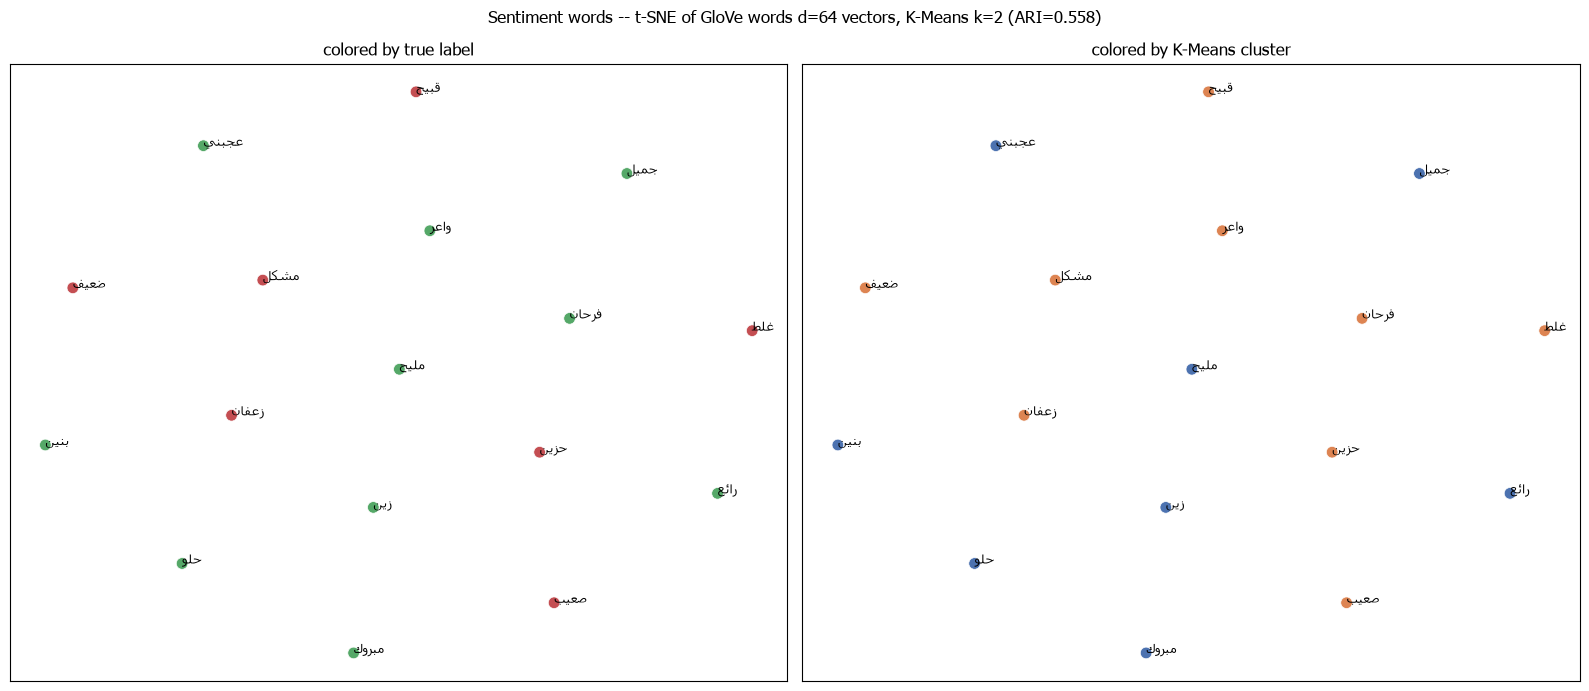

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

POSITIVE_WORDS = ["\u0645\u0644\u064a\u062d", "\u0632\u064a\u0646", "\u0641\u0631\u062d\u0627\u0646", "\u062d\u0644\u0648", "\u0639\u062c\u0628\u0646\u064a", "\u0631\u0627\u0626\u0639", "\u0645\u0628\u0631\u0648\u0643", "\u0628\u0646\u064a\u0646", "\u062c\u0645\u064a\u0644", "\u0648\u0627\u0639\u0631"]
# mlih, zin, farhan, hlou, 3ejbni, rai3, mabrouk, bnin, jmil, wa3er
NEGATIVE_WORDS = ["\u062e\u0627\u064a\u0628", "\u0642\u0628\u064a\u062d", "\u062d\u0632\u064a\u0646", "\u0632\u0639\u0641\u0627\u0646", "\u0645\u0634\u0643\u0644", "\u062a\u0639\u0628\u0627\u0646", "\u063a\u0644\u0637", "\u0635\u0639\u064a\u0628", "\u0645\u0642\u0631\u0641", "\u0636\u0639\u064a\u0641"]
# khayeb, qbih, hzin, za3fan, mochkel, t3ban, ghalt, s3ib, mqarref, dh3if


def build_word_group_vectors(groups: dict[str, list[str]], embed_fn=None):
    """Flattens a {label: [words]} dict into (X, words, true_labels),
    dropping any word get_word_vector can't produce a vector for (fully
    OOV under the tokenizer -- shouldn't happen for BPE, kept as a guard).
    """
    embed_fn = embed_fn or get_word_vector
    vecs, words, labels = [], [], []
    for label, ws in groups.items():
        for w in ws:
            v = embed_fn(w)
            if v is None:
                print(f"  skipping OOV: {w}")
                continue
            vecs.append(v)
            words.append(w)
            labels.append(label)
    return np.stack(vecs), words, labels


def plot_clustering(X, words, true_labels, true_colors, k, title, model_label=None):
    """Fits K-Means(k) on the raw vectors, projects the same vectors to 2D
    via t-SNE for visualization only, and plots true-label vs cluster-
    assignment side by side. Returns the fitted KMeans and the ARI.
    """
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    ari = adjusted_rand_score(true_labels, kmeans.labels_)
    print(f"Adjusted Rand Index (true label vs K-Means cluster): {ari:.3f}")

    perplexity = min(30, max(2, X.shape[0] - 1))
    coords = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca").fit_transform(X)

    cluster_palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    panels = [
        (axes[0], [true_colors[l] for l in true_labels], "colored by true label"),
        (axes[1], [cluster_palette[c % len(cluster_palette)] for c in kmeans.labels_], "colored by K-Means cluster"),
    ]
    for ax, point_colors, subtitle in panels:
        ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=70, edgecolors="white", linewidths=0.5)
        for i, w in enumerate(words):
            ax.annotate(render_label(w), (coords[i, 0], coords[i, 1]), fontsize=9)
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(f"{title} -- t-SNE of {model_label or MODEL_LABEL} vectors, K-Means k={k} (ARI={ari:.3f})")
    plt.tight_layout()
    plt.show()
    return kmeans, ari


sent_X, sent_words, sent_true_labels = build_word_group_vectors(
    {"positive": POSITIVE_WORDS, "negative": NEGATIVE_WORDS}
)
print(f"{sent_X.shape[0]} sentiment words, {sent_X.shape[1]} dims")

sent_colors = {"positive": "#55A868", "negative": "#C44E52"}
sent_kmeans, sent_ari = plot_clustering(sent_X, sent_words, sent_true_labels, sent_colors, k=2, title="Sentiment words")

## 5. Named-entity-type word clustering (unsupervised, K-Means k=4)

Same idea, four categories instead of two: hand-picked Algerian person names, locations,
organizations, and time/date words. K-Means (k=4, unsupervised) fit on the raw vectors, visualized with
the same true-label / cluster-assignment t-SNE pair as above.

32 entity words, 64 dims
Adjusted Rand Index (true label vs K-Means cluster): 0.828


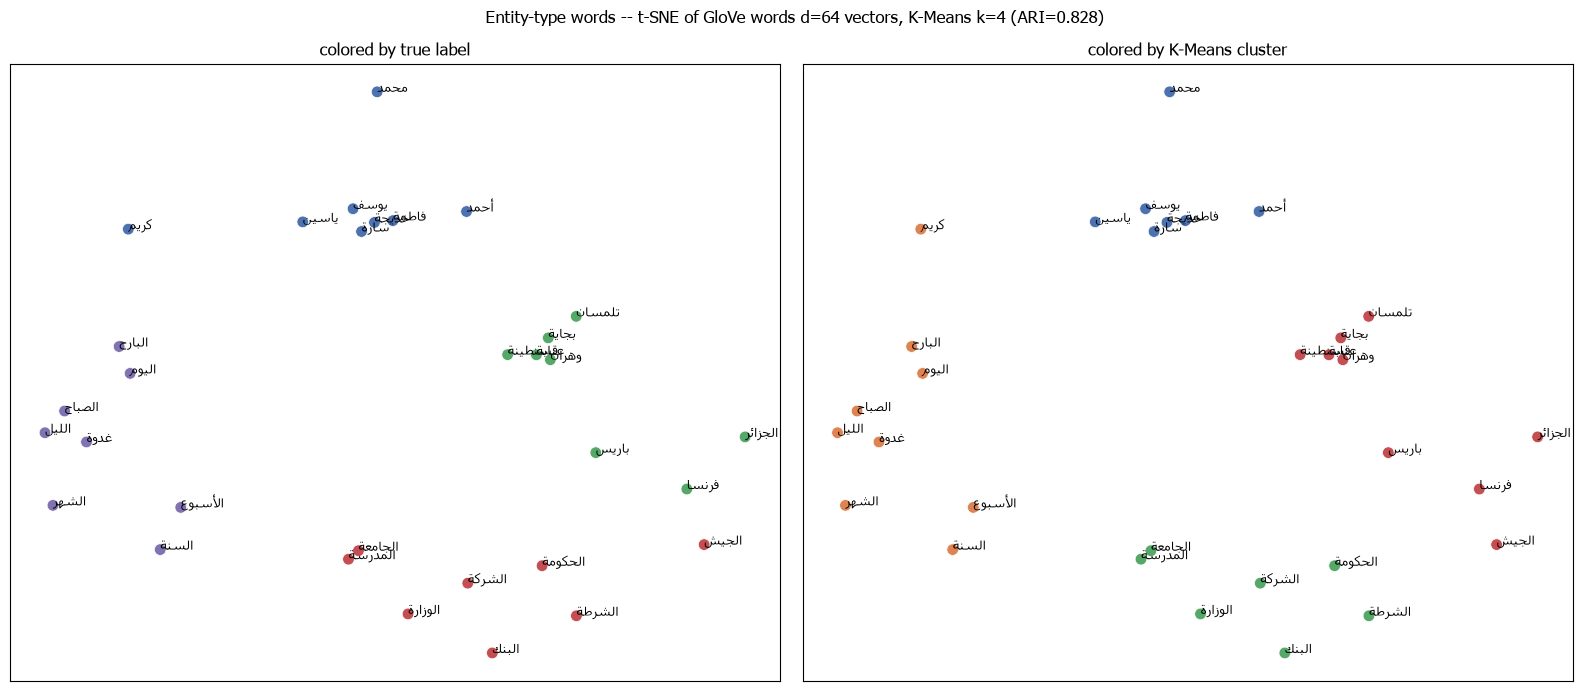

In [11]:
PERSON_WORDS = ["\u0645\u062d\u0645\u062f", "\u0623\u062d\u0645\u062f", "\u064a\u0648\u0633\u0641", "\u0633\u0627\u0631\u0629", "\u0641\u0627\u0637\u0645\u0629", "\u062e\u062f\u064a\u062c\u0629", "\u0643\u0631\u064a\u0645", "\u064a\u0627\u0633\u064a\u0646"]
# mohamed, ahmed, youcef, sara, fatima, khadija, karim, yacine
LOCATION_WORDS = ["\u0627\u0644\u062c\u0632\u0627\u0626\u0631", "\u0648\u0647\u0631\u0627\u0646", "\u0642\u0633\u0646\u0637\u064a\u0646\u0629", "\u0639\u0646\u0627\u0628\u0629", "\u062a\u0644\u0645\u0633\u0627\u0646", "\u0628\u062c\u0627\u064a\u0629", "\u0641\u0631\u0646\u0633\u0627", "\u0628\u0627\u0631\u064a\u0633"]
# el-djazair, wahran, qacentina, annaba, tlemcen, bejaia, france, paris
ORGANIZATION_WORDS = ["\u0627\u0644\u062d\u0643\u0648\u0645\u0629", "\u0627\u0644\u062c\u064a\u0634", "\u0627\u0644\u0634\u0631\u0637\u0629", "\u0627\u0644\u062c\u0627\u0645\u0639\u0629", "\u0627\u0644\u0648\u0632\u0627\u0631\u0629", "\u0627\u0644\u0628\u0646\u0643", "\u0627\u0644\u0634\u0631\u0643\u0629", "\u0627\u0644\u0645\u062f\u0631\u0633\u0629"]
# el-hokouma, el-jaych, e-chorta, el-jami3a, el-wizara, el-bank, e-charika, el-madrasa
TIME_DATE_WORDS = ["\u0627\u0644\u064a\u0648\u0645", "\u063a\u062f\u0648\u0629", "\u0627\u0644\u0628\u0627\u0631\u062d", "\u0627\u0644\u0635\u0628\u0627\u062d", "\u0627\u0644\u0644\u064a\u0644", "\u0627\u0644\u0623\u0633\u0628\u0648\u0639", "\u0627\u0644\u0634\u0647\u0631", "\u0627\u0644\u0633\u0646\u0629"]
# el-youm, ghdawa, el-bare7, e-sbah, el-lil, el-osbou3, e-chher, e-sena

ent_X, ent_words, ent_true_labels = build_word_group_vectors({
    "person": PERSON_WORDS,
    "location": LOCATION_WORDS,
    "organization": ORGANIZATION_WORDS,
    "time_date": TIME_DATE_WORDS,
})
print(f"{ent_X.shape[0]} entity words, {ent_X.shape[1]} dims")

ent_colors = {"person": "#4C72B0", "location": "#55A868", "organization": "#C44E52", "time_date": "#8172B2"}
ent_kmeans, ent_ari = plot_clustering(ent_X, ent_words, ent_true_labels, ent_colors, k=4, title="Entity-type words")

## 6. Words vs pieces on the clustering tasks

The same K-Means procedure (no plotting) with each model's vectors, on the words **both** models can
embed (so the word set is identical), reporting ARI against the hand-assigned labels. Small word lists
(10-32 words), so treat differences of a few hundredths as noise.

In [12]:
def ari_for(embed_fn, groups: dict[str, list[str]], k: int, common: list[str]):
    keep = set(common)
    vecs, labels = [], []
    for label, ws in groups.items():
        for w in ws:
            if w in keep:
                vecs.append(embed_fn(w))
                labels.append(label)
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(np.stack(vecs))
    return adjusted_rand_score(labels, km.labels_), len(vecs)


tasks = {
    "sentiment (k=2)": ({"positive": POSITIVE_WORDS, "negative": NEGATIVE_WORDS}, 2),
    "entity type (k=4)": ({"person": PERSON_WORDS, "location": LOCATION_WORDS,
                           "organization": ORGANIZATION_WORDS, "time_date": TIME_DATE_WORDS}, 4),
}
print(f"{'task':<20} {'words in common':>16} {'ARI words':>10} {'ARI pieces':>11}")
for task, (groups, k) in tasks.items():
    common = [w for ws in groups.values() for w in ws if get_word_vector_words(w) is not None]
    ari_w, n = ari_for(get_word_vector_words, groups, k, common)
    ari_p, _ = ari_for(get_word_vector_pieces, groups, k, common)
    total = sum(len(ws) for ws in groups.values())
    print(f"{task:<20} {n:>10}/{total:<5} {ari_w:>10.3f} {ari_p:>11.3f}")

task                  words in common  ARI words  ARI pieces
sentiment (k=2)              17/20         0.558       0.235
entity type (k=4)            32/32         0.828       0.914


## 7. GloVe d=128

A second `words`-mode model, same corpus/vocabulary/window/x_max/alpha as the d=64 model above (see
`plan.md`), just a higher embedding dimension. Trained by rerunning the pipeline (`select_corpus.py` ->
`tokenize_corpus.py --mode words` -> `build_cooccurrence.py --mode words` -> `train.py --mode words
--dim 128 --batch-size 32768 --tag _b32k`) -- the intermediate `corpus_10m.jsonl`/`tokens_words.npy`/
`cooc_words/` files from the original d=64 run had already been deleted to reclaim disk once that run
finished, so nothing from d=64's own run could be reused directly, only replicated identically (same
`vocab_words.json`, confirmed unchanged, so both models share one vocabulary and can be compared word
for word). Sections 8-11 below mirror sections 1, 2, 4 and 5 above exactly, for this model; section 12
puts the two dimensions side by side.

In [13]:
MODEL_LABEL_128 = "GloVe words d=128"
E_words_128 = np.load(MODELS_DIR / "glove_words_d128_b32k.npz")["embeddings"]
print(f"{MODEL_LABEL_128}: {E_words_128.shape}")


def get_word_vector_128(word: str) -> np.ndarray | None:
    i = word_id.get(word.lower())
    return None if i is None else E_words_128[i]

GloVe words d=128: (20000, 128)


## 8. t-SNE projection to 2D (d=128)

Same two groups as section 1 (frequent corpus words + curated Darija words), same t-SNE settings,
just embedded with the d=128 model instead of d=64.

t-SNE input: 631 points, 128 dims (123 curated words dropped as out-of-vocabulary)


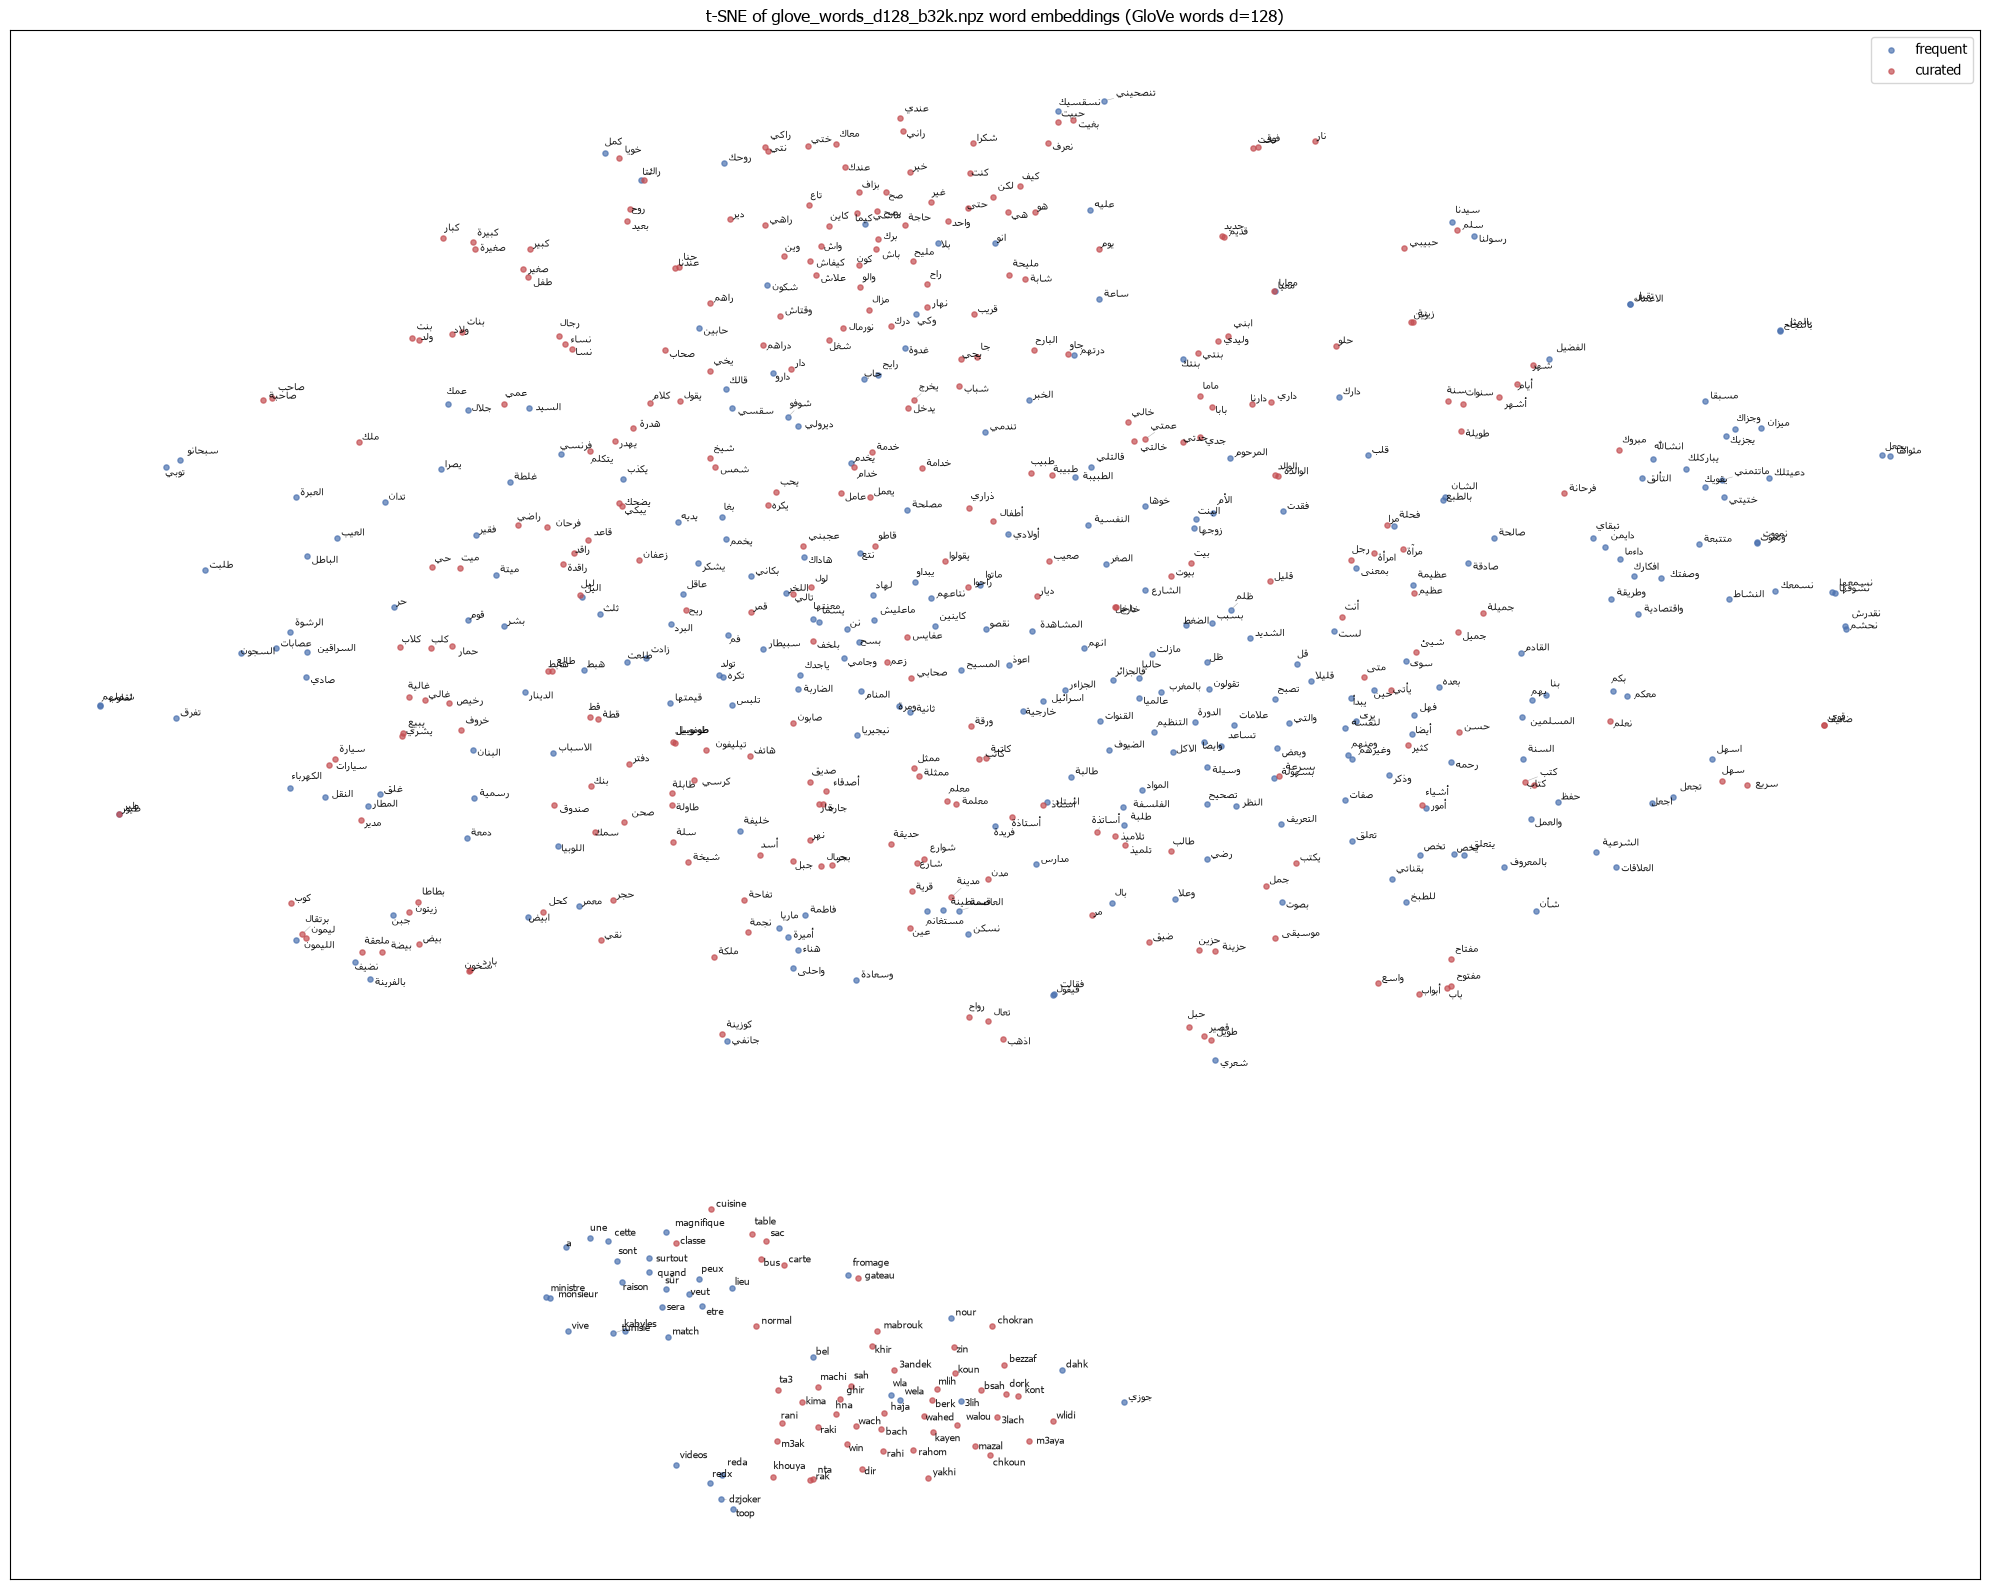

In [14]:
plot_vectors_128, plot_labels_128, plot_groups_128 = [], [], []

for w in frequent_words:
    v = get_word_vector_128(w)
    if v is not None:
        plot_vectors_128.append(v)
        plot_labels_128.append(w)
        plot_groups_128.append("frequent")

n_curated_oov_128 = 0
for w in curated_words_deduped:
    v = get_word_vector_128(w)
    if v is not None:
        plot_vectors_128.append(v)
        plot_labels_128.append(w)
        plot_groups_128.append("curated")
    else:
        n_curated_oov_128 += 1

X_128 = np.stack(plot_vectors_128)
print(f"t-SNE input: {X_128.shape[0]} points, {X_128.shape[1]} dims ({n_curated_oov_128} curated words dropped as out-of-vocabulary)")

tsne_128 = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
coords_128 = tsne_128.fit_transform(X_128)

fig, ax = plt.subplots(figsize=(20, 16))
for group in ("frequent", "curated"):
    idx = [i for i, g in enumerate(plot_groups_128) if g == group]
    ax.scatter(coords_128[idx, 0], coords_128[idx, 1], s=14, color=colors[group], alpha=0.7, label=group)

texts_128 = [
    ax.text(coords_128[i, 0], coords_128[i, 1], render_label(label), fontsize=7, alpha=0.9)
    for i, label in enumerate(plot_labels_128)
]
adjust_text(texts_128, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.6))

ax.set_title(f"t-SNE of glove_words_d128_b32k.npz word embeddings ({MODEL_LABEL_128})")
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

## 9. Nearest neighbors (d=128)

Same demo words and same whole-vocabulary ranking as section 2, using the d=128 vectors.

In [15]:
pool_normed_128 = E_words_128 / np.clip(np.linalg.norm(E_words_128, axis=1, keepdims=True), 1e-9, None)


def nearest_neighbors_128(word: str, k: int = 10) -> list[tuple[str, float]]:
    qv = get_word_vector_128(word)
    if qv is None:
        return []
    qv = qv / max(np.linalg.norm(qv), 1e-9)
    sims = pool_normed_128 @ qv
    results: list[tuple[str, float]] = []
    for i in np.argsort(-sims):
        w = vocab_words[i]
        if w == word.lower():
            continue
        results.append((w, float(sims[i])))
        if len(results) >= k:
            break
    return results


for w in demo_words + arabizi_demo_words:
    neighbors = nearest_neighbors_128(w, k=10)
    print(f"\n{w}:" + ("" if neighbors else "  (out of vocabulary)"))
    for nw, score in neighbors:
        print(f"  {score:.3f}  {nw}")


بزاف:
  0.912  بزااف
  0.861  بصح
  0.818  مي
  0.773  تاني
  0.767  والله
  0.764  صح
  0.760  كيما
  0.755  انا
  0.753  خاطر
  0.752  كامل

خدمة:
  0.699  الخدمة
  0.684  يخدم
  0.651  تخدم
  0.612  وخدمة
  0.593  خدام
  0.585  سكنة
  0.579  دراهم
  0.571  دار
  0.570  البلاد
  0.570  نخدم

واش:
  0.924  وش
  0.800  كيفاش
  0.794  برك
  0.792  كيما
  0.789  كي
  0.787  بصح
  0.773  علاه
  0.772  علاش
  0.772  المهم
  0.771  باش

حبيبي:
  0.623  حبيبنا
  0.589  حبيب
  0.582  خويا
  0.568  يارسول
  0.563  صديقي
  0.563  صاحبي
  0.560  الحبيب
  0.557  ابي
  0.537  محمد
  0.533  الغالي

مليح:
  0.785  برك
  0.778  كلش
  0.765  شوية
  0.757  بصح
  0.740  شوي
  0.731  كي
  0.729  مي
  0.718  باه
  0.715  باش
  0.711  ماشي

ولد:
  0.776  بنت
  0.724  ولاد
  0.640  اولاد
  0.623  وبنت
  0.606  وولد
  0.604  ابن
  0.592  أولاد
  0.592  فاميليا
  0.591  راجل
  0.584  عمي

بنت:
  0.776  ولد
  0.731  وبنت
  0.702  بنات
  0.688  خالتي
  0.658  بلادي
  0.658  ولاد
  0.600  طفلة
  0.597  راجل
  0

## 10. Sentiment word clustering (d=128)

Same hand-picked positive/negative word lists and same unsupervised K-Means(k=2) procedure as section 4.

  skipping OOV: خايب
  skipping OOV: تعبان
  skipping OOV: مقرف
17 sentiment words, 128 dims
Adjusted Rand Index (true label vs K-Means cluster): 0.558


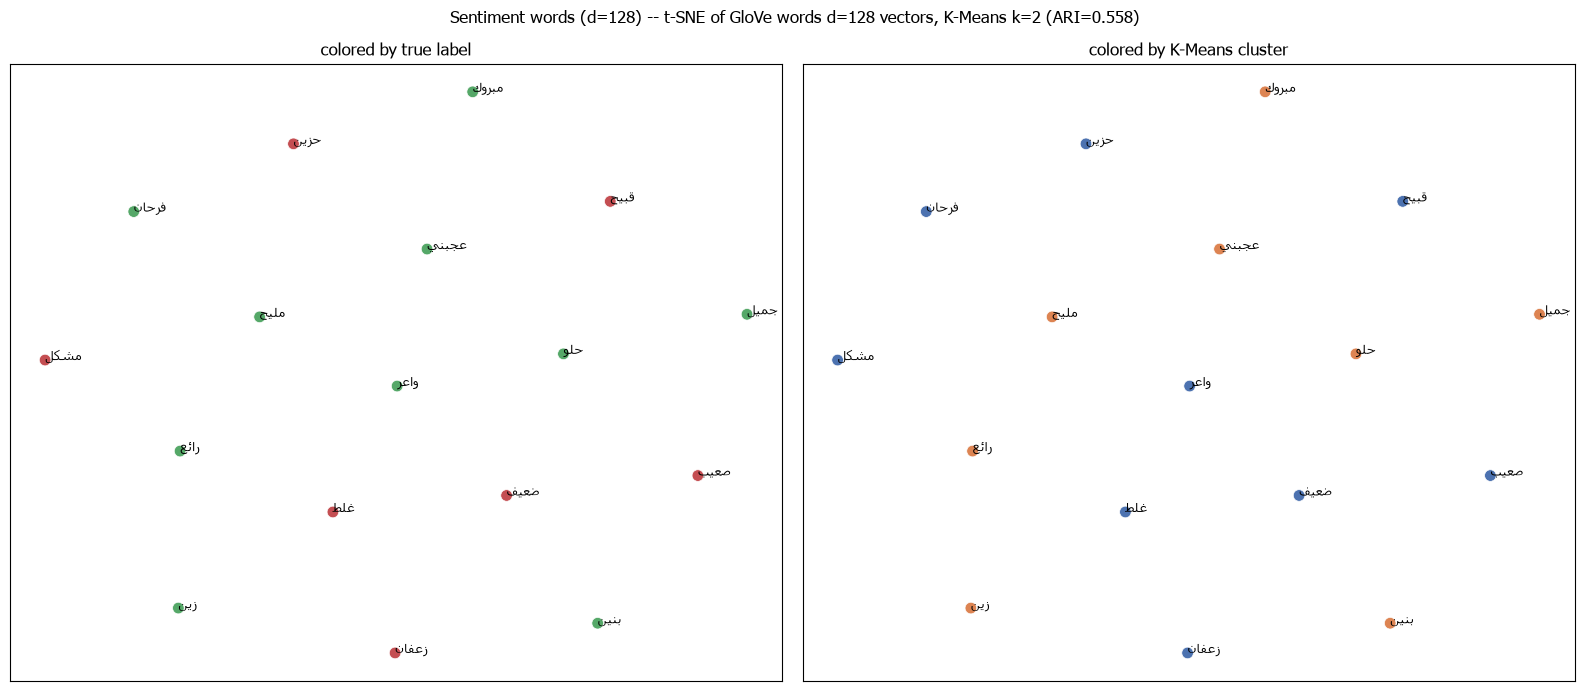

In [16]:
sent_X_128, sent_words_128, sent_true_labels_128 = build_word_group_vectors(
    {"positive": POSITIVE_WORDS, "negative": NEGATIVE_WORDS}, embed_fn=get_word_vector_128
)
print(f"{sent_X_128.shape[0]} sentiment words, {sent_X_128.shape[1]} dims")

sent_kmeans_128, sent_ari_128 = plot_clustering(
    sent_X_128, sent_words_128, sent_true_labels_128, sent_colors, k=2,
    title="Sentiment words (d=128)", model_label=MODEL_LABEL_128,
)

## 11. Named-entity-type word clustering (d=128)

Same word lists and same unsupervised K-Means(k=4) procedure as section 5.

32 entity words, 128 dims
Adjusted Rand Index (true label vs K-Means cluster): 0.914


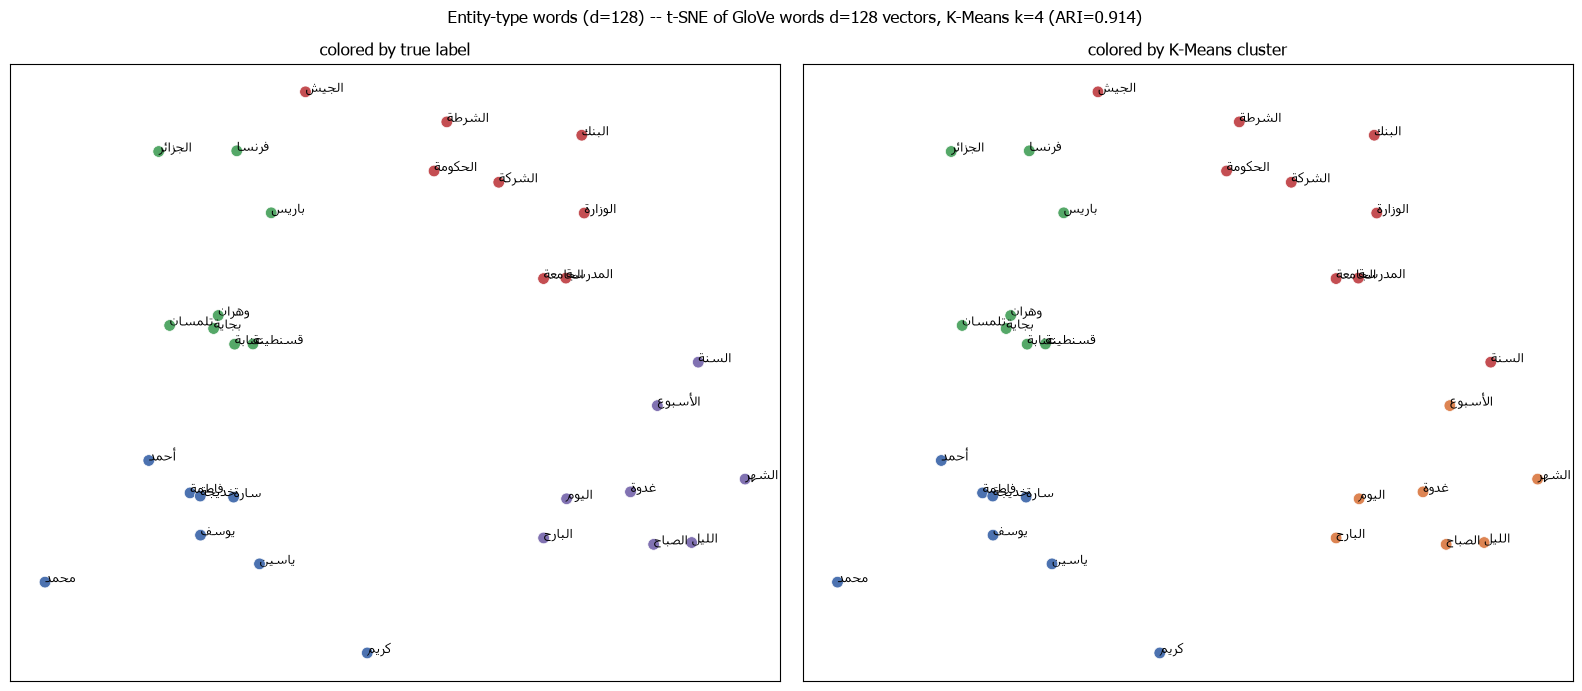

In [17]:
ent_X_128, ent_words_128, ent_true_labels_128 = build_word_group_vectors({
    "person": PERSON_WORDS, "location": LOCATION_WORDS,
    "organization": ORGANIZATION_WORDS, "time_date": TIME_DATE_WORDS,
}, embed_fn=get_word_vector_128)
print(f"{ent_X_128.shape[0]} entity words, {ent_X_128.shape[1]} dims")

ent_kmeans_128, ent_ari_128 = plot_clustering(
    ent_X_128, ent_words_128, ent_true_labels_128, ent_colors, k=4,
    title="Entity-type words (d=128)", model_label=MODEL_LABEL_128,
)

## 12. d=64 vs d=128 comparison

Same evaluation battery, run for both dimensions side by side: intrinsic word-similarity/analogy
accuracy, then the K-Means ARIs from sections 4/5/10/11. Both models share the same 20K-word
vocabulary, so every item scored for one is scored for the other -- a clean, confound-free comparison
of dimension alone (mode, corpus, window and training recipe are all held fixed).

In [18]:
print(f"{'variant':<10} {'sim rho':>8} {'scored/OOV':>11} {'analogy acc':>12} {'questions':>10}")
dim_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for label, fn in (("d=64", get_word_vector_words), ("d=128", get_word_vector_128)):
        s, a = evaluate_similarity(fn), evaluate_analogies(fn)
        dim_rows.append((label, s["overall_spearman"], s["n_pairs_scored"], s["n_pairs_oov"],
                          a["overall_accuracy"], a["overall_n_questions"], {c: r["accuracy"] for c, r in a["by_category"].items()}))
for label, rho, n_ok, n_oov, acc, n_q, _ in dim_rows:
    print(f"{label:<10} {rho:>8.4f} {n_ok:>5}/{n_oov:<5} {acc:>12.4f} {n_q:>10}")

print("\nAnalogy accuracy by category:")
cats = list(dim_rows[0][6])
print(f"{'category':<24}" + "".join(f"{r[0]:>10}" for r in dim_rows))
for c in cats:
    print(f"{c:<24}" + "".join(f"{r[6][c]:>10.3f}" for r in dim_rows))

print(f"\n{'task':<20} {'ARI d=64':>10} {'ARI d=128':>11}")
print(f"{'sentiment (k=2)':<20} {sent_ari:>10.3f} {sent_ari_128:>11.3f}")
print(f"{'entity type (k=4)':<20} {ent_ari:>10.3f} {ent_ari_128:>11.3f}")

variant     sim rho  scored/OOV  analogy acc  questions


d=64        -0.4512   136/79          0.2986       3309
d=128       -0.4445   136/79          0.3324       3309

Analogy accuracy by category:
category                      d=64     d=128
gender                       0.705     0.763
singular_plural              0.444     0.494
script_transliteration       0.088     0.107

task                   ARI d=64   ARI d=128
sentiment (k=2)           0.558       0.558
entity type (k=4)         0.828       0.914


### Reading the comparison

More dimensions give GloVe strictly more room to place words, but the corpus/vocabulary/training
budget here are unchanged from the d=64 run -- if d=128 doesn't clearly beat d=64 on most of the
numbers above, that says the bottleneck for this model is data/training, not embedding capacity, and
the smaller, cheaper d=64 model is the more practical choice to keep using. If d=128 wins clearly and
consistently, it's worth promoting to the default (`models/best.json`) instead -- not done automatically
here, since that's a deliberate choice, not something to flip silently based on one run.